In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df_train = pd.read_csv('/data/train.csv')
df_metadata = pd.read_csv('/data/metaData.csv')
df_train.sample(5)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
51,30421787,1,0.000000,1,40.083304,0.0,0.0,0.0,3.715602,0.0,...,0.0,0.000000,0.000000,0.0,0.0,3,4,8,65.084929,0
53,31560147,2,0.338525,1,0.346640,0.0,0.0,0.0,0.297613,0.0,...,0.0,0.003611,0.003611,-0.0,0.0,20,0,6,13.656787,1
62,34940889,5,4.088956,0,58.197413,0.0,0.0,0.0,4.080878,0.0,...,0.0,-0.395498,0.395498,0.0,-0.0,19,0,8,0.001220,1
151,69788114,1,0.000000,1,51.470443,0.0,0.0,0.0,3.960250,0.0,...,0.0,0.000000,0.000000,0.0,0.0,16,2,7,20.872944,1
143,66725353,1,0.000000,1,2.062098,0.0,0.0,0.0,1.119100,0.0,...,0.0,0.000000,0.000000,0.0,0.0,16,2,7,55.170610,1


In [21]:
info_df = pd.DataFrame({
    "column": df_train.columns,
    "non_null_count": df_train.notnull().sum().values,
    
    "dtype": df_train.dtypes.values
})

info_df

,column,non_null_count,dtype
0,event_id,221,int64
1,num_perimeters_0_5h,221,int64
2,dt_first_last_0_5h,221,float64
3,low_temporal_resolution_0_5h,221,int64
4,area_first_ha,221,float64
5,area_growth_abs_0_5h,221,float64
6,area_growth_rel_0_5h,221,float64
7,area_growth_rate_ha_per_h,221,float64
8,log1p_area_first,221,float64
9,log1p_growth,221,float64


In [22]:
# COLUMN TYPE GROUPING


# TARGET + IDENTIFIER


ID_COL = ["event_id"]
TARGET_COLS = ["time_to_hit_hours", "event"]


# CATEGORICAL COUNT FEATURES


categorical_count = [
    "num_perimeters_0_5h"
]


# TIME / TEMPORAL FEATURES


time_features = [
    "dt_first_last_0_5h",
    "event_start_hour",
    "event_start_dayofweek",
    "event_start_month"
]


# BINARY / LOW CARDINALITY FEATURES


categorical = [
    "low_temporal_resolution_0_5h"
]


# CONTINUOUS FEATURES


continuous = [
    "area_first_ha",
    "area_growth_abs_0_5h",
    "area_growth_rel_0_5h",
    "area_growth_rate_ha_per_h",
    "log1p_area_first",
    "log1p_growth",
    "log_area_ratio_0_5h",
    "relative_growth_0_5h",
    "radial_growth_m",
    "radial_growth_rate_m_per_h",
    "centroid_displacement_m",
    "centroid_speed_m_per_h",
    "spread_bearing_deg",
    "spread_bearing_sin",
    "spread_bearing_cos",
    "dist_min_ci_0_5h",
    "dist_std_ci_0_5h",
    "dist_change_ci_0_5h",
    "dist_slope_ci_0_5h",
    "closing_speed_m_per_h",
    "closing_speed_abs_m_per_h",
    "projected_advance_m",
    "dist_accel_m_per_h2",
    "dist_fit_r2_0_5h",
    "alignment_cos",
    "alignment_abs",
    "cross_track_component",
    "along_track_speed"
]


# ALL FEATURES


ALL_FEATURES = continuous + categorical + categorical_count + time_features

print("Continuous:", len(continuous))
print("Categorical:", len(categorical))
print("Categorical Count:", len(categorical_count))
print("Time Features:", len(time_features))
print("Total Features:", len(ALL_FEATURES))


Continuous: 28
Categorical: 1
Categorical Count: 1
Time Features: 4
Total Features: 34


In [23]:
df_train_cleaned = df_train.copy()

In [24]:
df_train['low_temporal_resolution_0_5h'].unique()

array([0, 1])

In [25]:
df_train['num_perimeters_0_5h'].unique()

array([ 3,  2,  4,  1, 12,  7,  9,  5,  6, 11, 13, 17])

# Temporal Unique Values

In [26]:
for i in time_features:
    print(f"\n{i}")
    print(df_train[i].unique())



dt_first_last_0_5h
[4.26518831 1.16991766 4.77752603 0.         4.97527303 1.89277576
 3.00396594 4.86563511 4.30869465 4.99445712 4.81428168 3.90112327
 4.25638072 3.79855304 2.33649392 4.01788295 4.95812829 0.33852454
 3.91346827 4.08895595 4.80051781 1.42418807 4.58118365 4.85404251
 4.98069594 4.82981508 4.79764045 2.07819177 3.28915809 4.49911703
 2.99880586 1.35610697 4.56779782 4.81905085 2.08615476 4.58317129
 4.49195268 4.64551789 4.52739219 4.64081332 3.76802964 3.06899239
 2.27850839 4.78921807 2.93229394 4.71036545 1.57532289 2.02857597
 1.22100235 2.02459903 4.07375318 3.16456337 4.0856005  4.5596047
 1.92127844 1.87567809 4.16325249 0.9115856  4.1111247  4.92136577
 1.12710234 3.71065274]

event_start_hour
[19  4 22 20 21  0 16 18 17 23 14  2  8  1  6  3  5 12 13  9 15 10]

event_start_dayofweek
[4 5 1 0 2 3 6]

event_start_month
[5 6 8 7 3 9 4 2 1]


### Validation of Temporal Features

The temporal metadata variables were checked against their expected ranges based on the dataset documentation.

- `dt_first_last_0_5h` values fall within the expected 0–5 hour range.
- `event_start_hour` values are within the valid 0–23 hour range.
- `event_start_dayofweek` correctly spans values from 0 (Monday) to 6 (Sunday).
- `event_start_month` values fall within the valid range of 1–12, although only months 1–9 appear in the dataset.

Overall, all temporal features are consistent with the metadata definitions and require no additional preprocessing.

# Continuous Unique Values

In [27]:
for i in continuous:
    print(f"\n{i}")
    print(df_train[i].unique())


area_first_ha
[7.96963044e+01 8.94674938e+00 1.06482638e+02 6.76311247e+01
 3.56328735e+01 1.84767610e+02 1.19364203e+02 1.38828378e+03
 4.49397016e+00 5.21852444e+00 6.34480139e+02 1.17219890e+02
 1.73420133e+01 4.92582584e+01 3.66834593e+01 1.74927872e+03
 1.47357925e+02 9.16708521e+00 2.52190577e+01 3.63872998e+03
 1.25587802e+03 1.33189234e+02 7.14105964e+01 3.23073677e+02
 1.93311183e+02 3.77264264e+01 1.06487707e+02 4.24788220e+02
 5.15490809e+02 2.30000905e+03 2.55035402e+02 6.55204179e+01
 1.77722509e+01 2.15788508e+02 3.31603740e+03 2.99242702e+01
 8.45113964e+02 1.49573065e+01 3.96046287e+02 3.43482778e+03
 2.01706265e+01 2.24404129e+01 3.51187317e+01 1.21024945e+01
 1.68229667e+03 7.34086868e+01 1.13226932e+03 1.67279235e+01
 6.31991837e+03 3.16050328e+02 3.74205773e+00 4.00833037e+01
 7.58077049e+02 3.46640246e-01 1.13560832e+03 4.66042515e+01
 1.68685092e+03 6.30127420e+00 5.15020472e+02 3.82164591e+01
 5.38803959e+02 2.98486431e+02 5.81974131e+01 1.77012073e+02
 1.009936

# Replacing Wrong Data

Tiny Negative Noise → Replace with 0

area_growth_abs_0_5h<br>
area_growth_rel_0_5h<br>
area_growth_rate_ha_per_h<br>
log_area_ratio_0_5h<br>
radial_growth_m<br>
radial_growth_rate_m_per_h<br>
dist_slope_ci_0_5h<br>
dist_accel_m_per_h2

In [28]:
noise_cols = [
    "area_growth_abs_0_5h",
    "area_growth_rel_0_5h",
    "area_growth_rate_ha_per_h",
    "log_area_ratio_0_5h",
    "radial_growth_m",
    "radial_growth_rate_m_per_h"
]

for col in noise_cols:
    df_train_cleaned[col] = df_train_cleaned[col].clip(lower=0)

# Checking Dupliates

In [29]:
df_metadata.duplicated().sum()

np.int64(0)

# Missing Values

In [30]:
df_train.isnull().sum()

event_id                        0
num_perimeters_0_5h             0
dt_first_last_0_5h              0
low_temporal_resolution_0_5h    0
area_first_ha                   0
area_growth_abs_0_5h            0
area_growth_rel_0_5h            0
area_growth_rate_ha_per_h       0
log1p_area_first                0
log1p_growth                    0
log_area_ratio_0_5h             0
relative_growth_0_5h            0
radial_growth_m                 0
radial_growth_rate_m_per_h      0
centroid_displacement_m         0
centroid_speed_m_per_h          0
spread_bearing_deg              0
spread_bearing_sin              0
spread_bearing_cos              0
dist_min_ci_0_5h                0
dist_std_ci_0_5h                0
dist_change_ci_0_5h             0
dist_slope_ci_0_5h              0
closing_speed_m_per_h           0
closing_speed_abs_m_per_h       0
projected_advance_m             0
dist_accel_m_per_h2             0
dist_fit_r2_0_5h                0
alignment_cos                   0
alignment_abs 

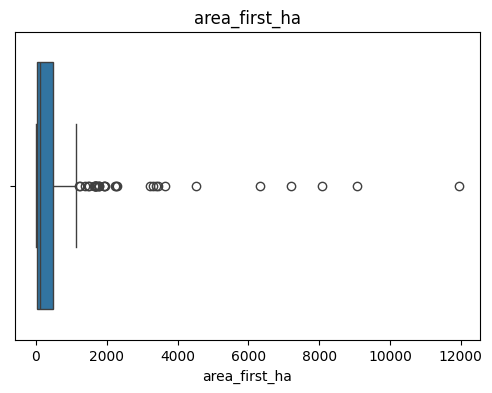

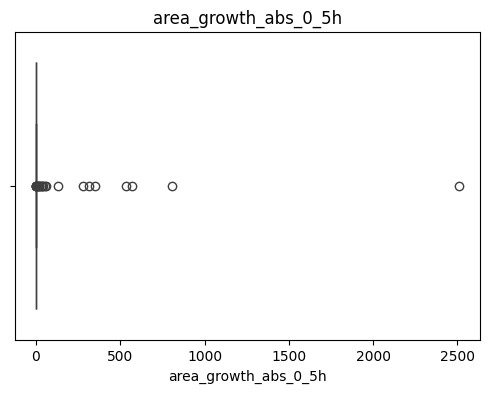

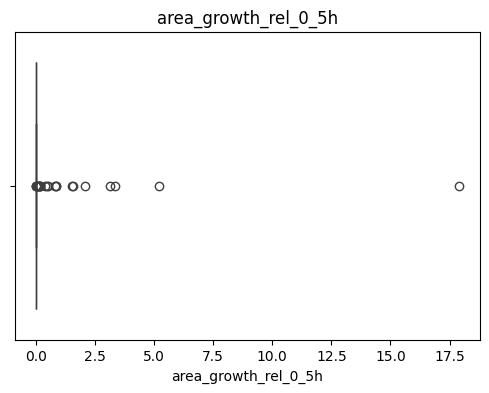

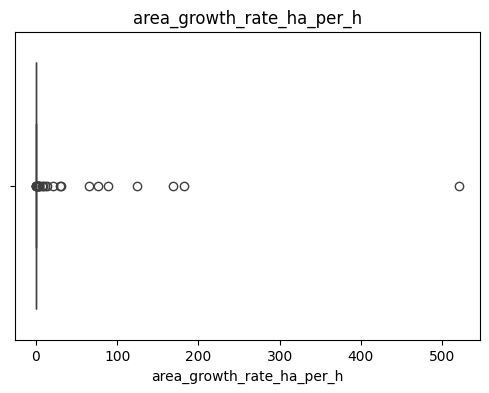

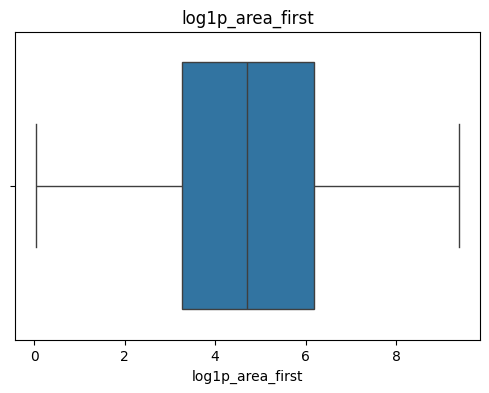

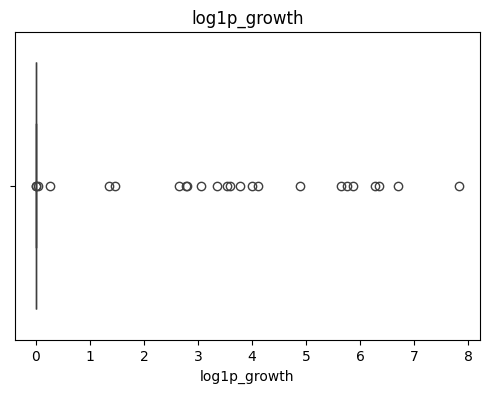

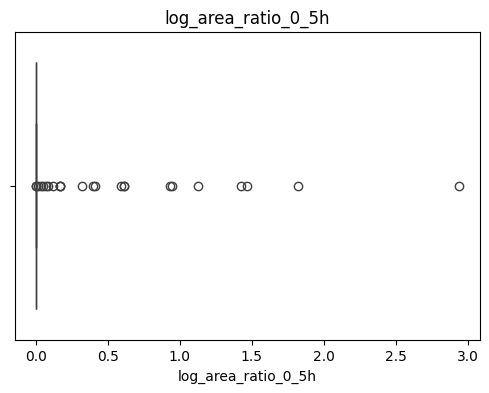

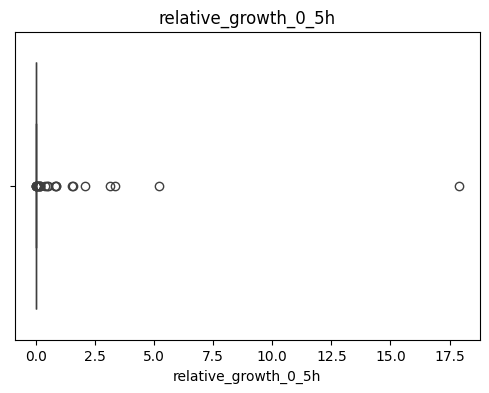

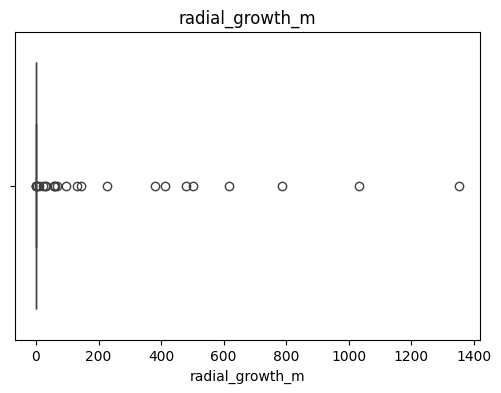

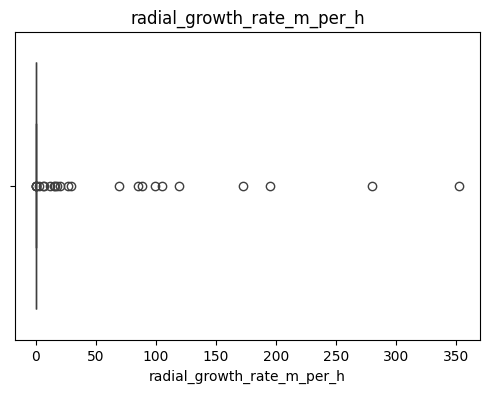

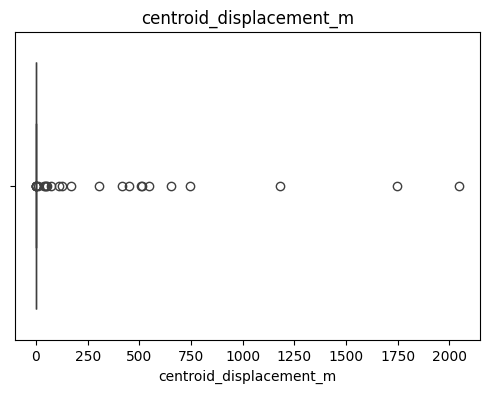

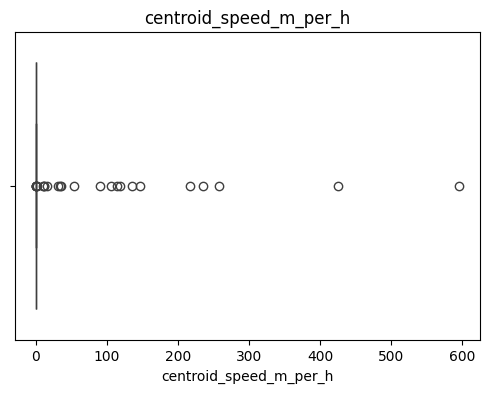

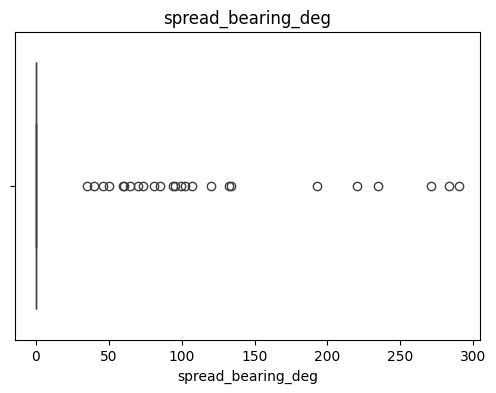

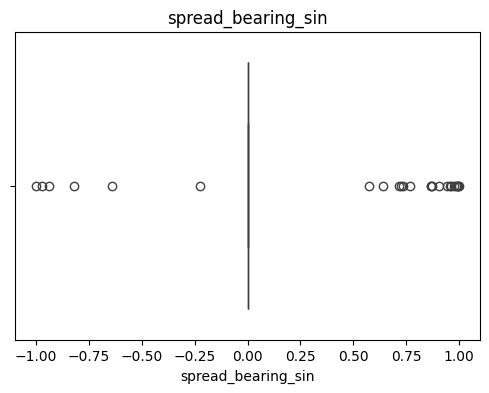

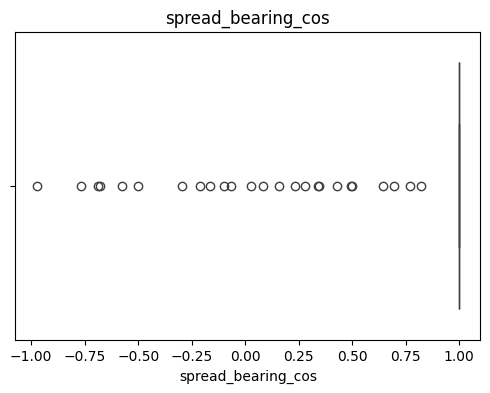

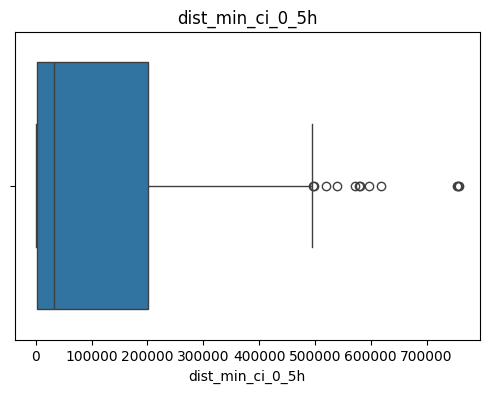

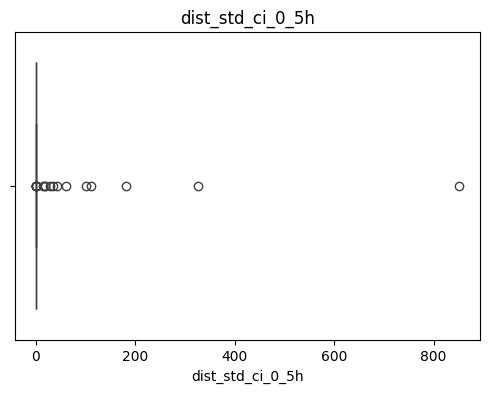

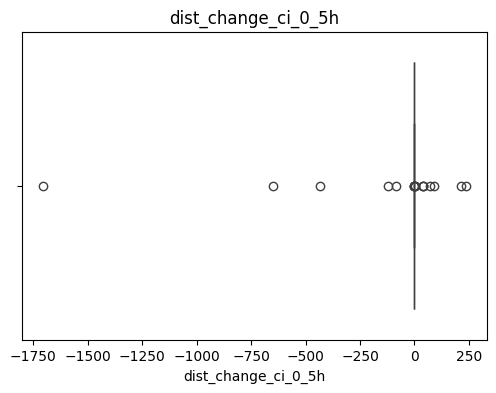

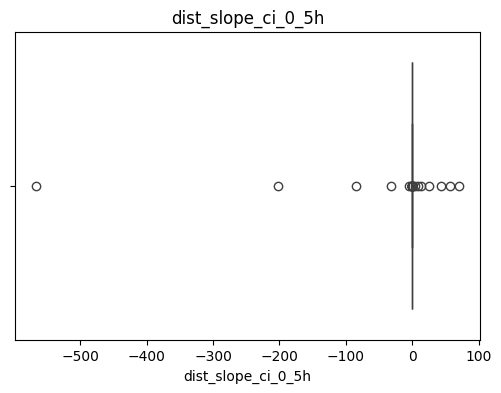

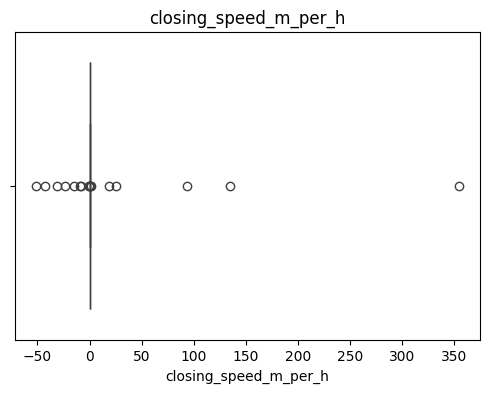

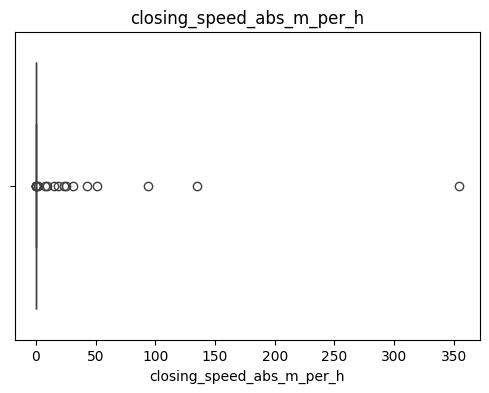

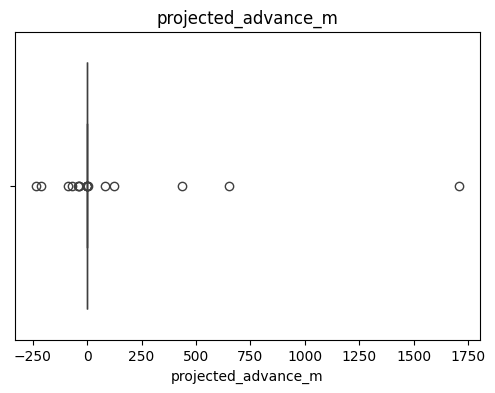

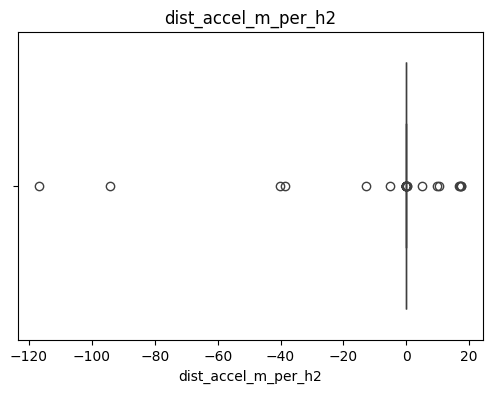

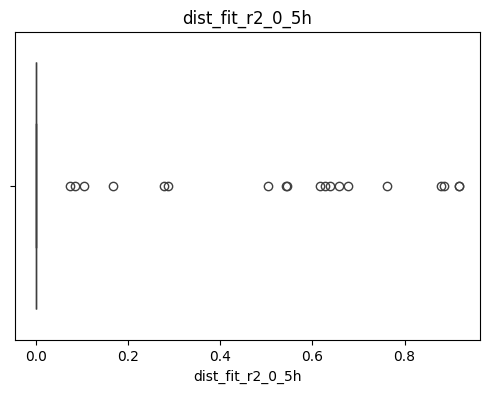

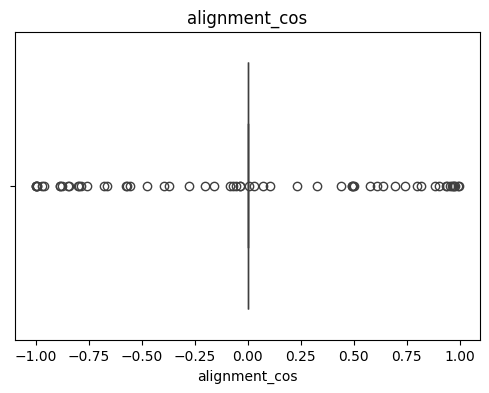

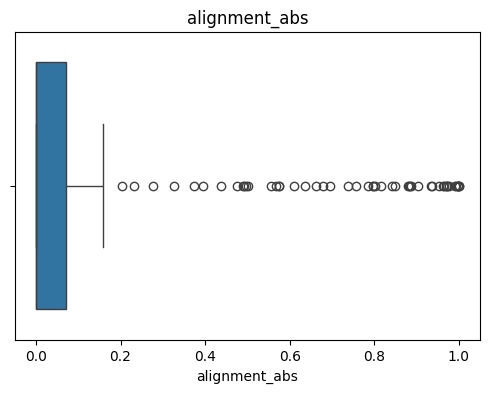

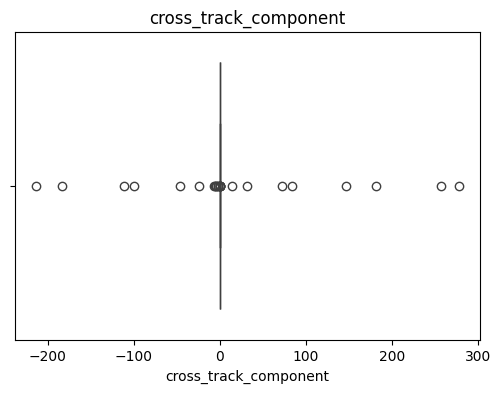

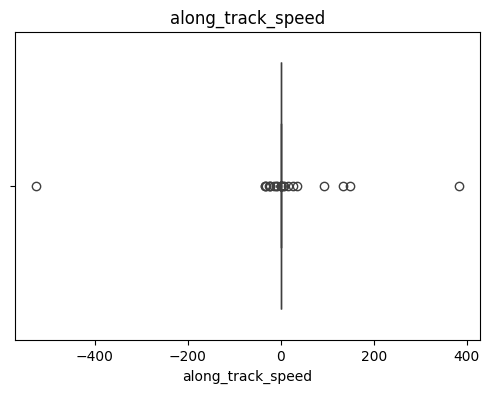

In [31]:
# update continuous list
valid_continuous = [col for col in continuous if col in df_train_cleaned.columns]

# boxplots
for i in valid_continuous:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_train_cleaned[i])
    plt.title(i)
    plt.show()

### Outlier Handling

Boxplots revealed the presence of several extreme values in the dataset. 
However, these values represent realistic wildfire behavior such as very large fires or fires located far from evacuation zones. 

Since the dataset is small and tree-based models are robust to outliers, these observations were retained to preserve important information about extreme wildfire events.


`HINDI`<br>
dataset me jo outliers dikh rahe hain
wo actual wildfire events ho sakte hain
isliye unhe remove nahi kiya gaya

sirf measurement noise values ko clean kiya gaya
taaki real extreme fires dataset me remain karein

In [32]:
df_train_cleaned.to_csv("../data/train_cleaned.csv", index=False)

### Saving Cleaned Dataset

A cleaned copy of the training dataset was created to preserve the original data. 
All preprocessing steps were applied to this new dataset, which was then saved for use in the modeling phase.